<a href="https://colab.research.google.com/github/orcasandpandas/Data-Science-Cohort-20/blob/main/Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project SQL - Chinook


## Chinook data set

See the lecture on SQLite3 using the Chinook data set to set up the software, database, and tables, as well as for the links to ancillary information about the data set.


In [ ]:
# Install the sqlite package for Ubuntu
%%capture
%%bash
apt-get update
apt-get install -y sqlite3
pip install sqlite-web

In [ ]:
%%bash
# Download the Chinook sqlite database
[ -f chinook.zip ] ||
  curl -s -O https://www.sqlitetutorial.net/wp-content/uploads/2018/03/chinook.zip

unzip -u chinook.zip


Archive:  chinook.zip
  inflating: chinook.db              


In [ ]:
from google.colab import output
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sqlite3 as db



## Come up with questions about your data
Have a look at the Entity-Relation ( ER ) diagram to help come up with questions.

* What sort of information is in this dataset?
* How many records are there?
* How many different countries (states, counties, cities, etc) have records in this data set?


If you are stuck, here are some ideas for questions:
- https://github.com/LucasMcL/15-sql_queries_02-chinook/blob/master/README.md
- [Using the R language]( https://rpubs.com/enext777/636199 )
- [Search Google]( https://www.google.com/search?q=chinook+database+questions )



In [ ]:
# Python dataframes look nice!
def run_query(q):
    # Hardcode the database name inside the function
    with db.connect("chinook.db") as db_con:
        return pd.read_sql_query(q, db_con)

## Use SQL queries to pull specific information

Do NOT pull all the data and then filter using DataFrame methods etc. Make sure and use AT LEAST 13 of the 15 SQL options listed below. (You may have to get creative and come up with more questions to ask/answer.)


In [ ]:
# @title Querying using sqlite-web
%%capture output
%%bash

tmux new -s sqlite_web -d " \
  sqlite_web chinook.db -p 9080 ;\
  echo == Done ; \
  sleep 30
"



In [ ]:
from google.colab.output import serve_kernel_port_as_iframe

serve_kernel_port_as_iframe(9080)


<IPython.core.display.Javascript object>

### Basic Queries


#### SELECT (with * and with column names)


In [ ]:
df = run_query('SELECT CustomerId, BillingAddress, InvoiceDate FROM invoices')
df

,CustomerId,BillingAddress,InvoiceDate
0,2,Theodor-Heuss-Straße 34,2009-01-01 00:00:00
1,4,Ullevålsveien 14,2009-01-02 00:00:00
2,8,Grétrystraat 63,2009-01-03 00:00:00
3,14,8210 111 ST NW,2009-01-06 00:00:00
4,23,69 Salem Street,2009-01-11 00:00:00
...,...,...,...
407,25,319 N. Frances Street,2013-12-05 00:00:00
408,29,796 Dundas Street West,2013-12-06 00:00:00
409,35,"Rua dos Campeões Europeus de Viena, 4350",2013-12-09 00:00:00
410,44,Porthaninkatu 9,2013-12-14 00:00:00


#### WHERE


In [ ]:
df = run_query('''
SELECT Name, Composer, Milliseconds, UnitPrice
FROM tracks
WHERE Milliseconds > 1000000
''')
df

#### AND


In [ ]:
df = run_query('''
SELECT FirstName, LastName, Title, Phone, HireDate
FROM Employees
WHERE HireDate >= '1-04-2002' AND City = 'Calgary'
''')
df

#### OR


In [ ]:
df = run_query('''
SELECT *
FROM albums
WHERE ArtistId in (
  SELECT ArtistId from artists
  WHERE name = 'AC/DC' OR name = 'Emerson String Quartet' )
''')
df

#### LIKE (with % or _ wildcard)


In [ ]:
df = run_query('''
SELECT FirstName, LastName, Phone
FROM customers
WHERE Phone like '+1%'
''')
df

#### BETWEEN


In [ ]:
df = run_query('''
SELECT *
FROM Invoices
WHERE InvoiceDate BETWEEN '2010-07-20' AND '2011-07-20'
''')
df

NameError: name 'run_query' is not defined

#### LIMIT



In [ ]:
df = run_query('''
SELECT *
FROM invoice_items
LIMIT 20
''')
df

### Sorting and Grouping


#### ORDER BY


In [ ]:
df = run_query('''
SELECT Name, Composer, Milliseconds, Bytes, UnitPrice
FROM tracks
ORDER BY 'Milliseconds'
''')
df

#### DISTINCT


In [ ]:
df = run_query('''
SELECT DISTINCT City, Country
FROM Customers
''')
df

NameError: name 'run_query' is not defined

#### GROUP BY



In [ ]:
df = run_query('''
SELECT Title, COUNT(EmployeeID) AS [Number of Employees]
FROM Employees
GROUP BY Title
ORDER BY COUNT(EmployeeID) DESC
''')
df

### Aggregates


#### MAX


In [ ]:
df =run_query('''
SELECT MAX (StateCount), State
FROM(SELECT Count(State) as StateCount, State
  FROM Customers
  GROUP BY State
)
''')
df

#### MIN


In [ ]:
df=run_query('''
    SELECT MIN(GenreCount), GenreId
    FROM(
        SELECT Count(GenreId) as GenreCount, GenreId
        FROM tracks
        GROUP BY GenreId )
''')
df

NameError: name 'run_query' is not defined

#### SUM


In [ ]:
df=run_query('''
SELECT SUM(UnitPrice) AS 'AC/DC Total Price'
FROM Invoice_Items
WHERE TrackId in
  (
    SELECT TrackId
    FROM tracks
    WHERE Composer = 'AC/DC'
  )
''')
df

#### AVG


In [ ]:
df=run_query('''
SELECT AVG(Bytes) AS 'Average Bytes'
FROM tracks
WHERE Composer = 'AC/DC'
''')
df

,Average Bytes
0,10029878.0


#### COUNT



In [ ]:
df=run_query('''
SELECT COUNT(CustomerId) AS 'Foreign Customers'
FROM Customers
WHERE NOT Country = 'USA'
''')
df

,Foreign Customers
0,46


## Make some plots

Make some cool plots to go with your data. Write SQL queries to get ONLY the information you need for each plot. (Don't pull ALL the data and then just plot a few columns.)



In [ ]:
df=run_query('''
SELECT g.Name AS 'Genre', SUM(ii.Quantity) as 'amount_sold', md.Name as 'Media Type'
FROM tracks AS t
JOIN genres AS g ON t.GenreId = g.GenreId
JOIN invoice_items ii ON t.Trackid = ii.TrackId
JOIN media_types md ON t.MediaTypeId = md.MediaTypeId
GROUP BY g.Name
''')

df['Media Type'] = df['Media Type'].replace('Protected MPEG-4 video file', 'Video')
df['Media Type'] = df['Media Type'].replace(['MPEG audio file', 'Protected AAC audio file', 'AAC audio file'], 'Audio')

df

,Genre,amount_sold,Media Type
0,Alternative,14,Audio
1,Alternative & Punk,244,Audio
2,Blues,61,Audio
3,Bossa Nova,15,Audio
4,Classical,41,Audio
5,Comedy,9,Video
6,Drama,29,Video
7,Easy Listening,10,Audio
8,Electronica/Dance,12,Audio
9,Heavy Metal,12,Audio


In [ ]:
df=run_query('''
SELECT t.Name AS Track, mt.Name AS Format
FROM tracks as t
JOIN media_types mt ON t.MediaTypeId = mt.MediaTypeId
JOIN genres g ON t.GenreId = g.GenreId
WHERE g.Name = 'Rock'
''')


df['Format'] = df['Format'].replace(['MPEG audio file', 'Protected AAC audio file', 'AAC audio file'], 'Audio')

df

,Track,Format
0,For Those About To Rock (We Salute You),Audio
1,Balls to the Wall,Audio
2,Fast As a Shark,Audio
3,Restless and Wild,Audio
4,Princess of the Dawn,Audio
...,...,...
1292,Tease Me Please Me,Audio
1293,Wind of Change,Audio
1294,Send Me an Angel,Audio
1295,I Guess You're Right,Audio


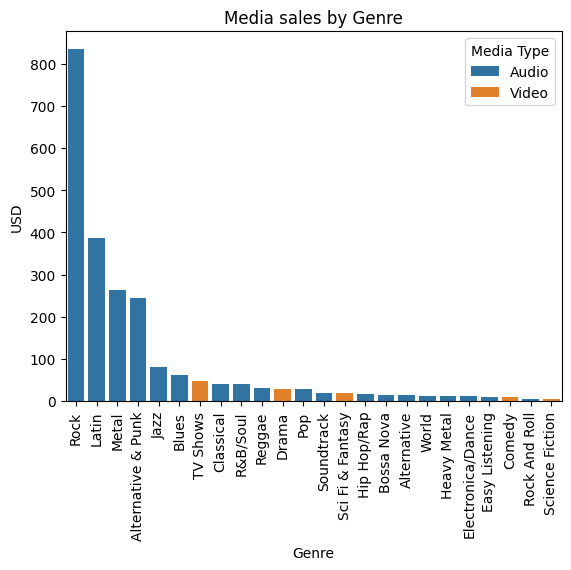

In [ ]:
df = df.sort_values(by='amount_sold', ascending=False)
plot = sns.barplot(data=df, x='Genre', y='amount_sold', hue='Media Type')
plt.xticks(rotation=90)
plt.title("Media sales by Genre")
plt.ylabel("USD")
plt.show()

## EXTRA CREDIT:
* Use a CTE
* Use a query that joins two or more tables.
* Make a model to see if you can predict something
* Come up with something else cool to do with your data


In [ ]:
df=run_query('''
SELECT strftime('%Y', InvoiceDate) AS Year, SUM(Total) AS USD
FROM invoices AS i
GROUP BY Year;
''')
df



,Year,USD
0,2009,449.46
1,2010,481.45
2,2011,469.58
3,2012,477.53
4,2013,450.58


<Axes: xlabel='Year'>

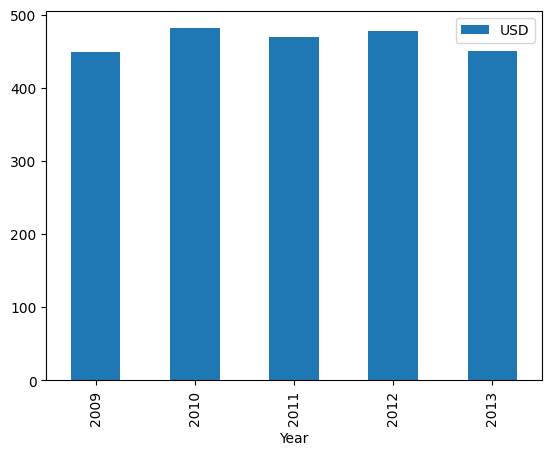

In [ ]:
df.plot(kind = 'bar', x = 'Year')